# Project-Part 2

Team Members:

- Liad Malachi: 212452882
- Shirel Elmaleh: 345653984

Github: https://github.com/Shirelmaleh/Machine-Learning/tree/main

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import re
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from IPython.display import display

# 2. Input Data and Target Variable

In [2]:
df = pd.read_csv('dataset.csv')
display(df.head())
df.info()

C:\Users\shire\AppData\Local\Temp\ipykernel_30488\2839346186.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('dataset.csv')


,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,numVotes,budget,BoxOffice,plot
0,tt0107274,Johnny One Hundred Pesos,1993.0,"Crime,Drama,Thriller","['nm0032843', 'nm0729381', 'nm0783839', 'nm066...",90.0,6.6,Spanish,Chile,711.0,NaN,NaN,NaN
1,tt32133209,It Doesn't Matter,2024.0,Drama,"['nm3571592', 'nm6238285', 'nm2541664', 'nm161...",86.0,6.1,NaN,NaN,23.0,NaN,NaN,NaN
2,tt31852671,If Love Deceives You,2024.0,"Drama,Romance",NaN,90.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,tt0312835,Je Vous Salue Raí,1993.0,Documentary,NaN,60.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,tt0765142,"If You Love Me, Follow Me",2006.0,Comedy,"['nm0218843', 'nm0693844', 'nm0220017', 'nm000...",102.0,6.1,NaN,NaN,248.0,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133884 entries, 0 to 133883
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   tconst           133884 non-null  object 
 1   primaryTitle     133884 non-null  object 
 2   startYear        133884 non-null  float64
 3   genres           131311 non-null  object 
 4   lead_actors_ids  123854 non-null  object 
 5   runtimeMinutes   133884 non-null  float64
 6   averageRating    115560 non-null  float64
 7   Language         55722 non-null   object 
 8   Country          53681 non-null   object 
 9   numVotes         124762 non-null  float64
 10  budget           16550 non-null   object 
 11  BoxOffice        17916 non-null   float64
 12  plot             59669 non-null   object 
dtypes: float64(5), object(8)
memory usage: 13.3+ MB


We will check the missing values in the table:

In [3]:
missing_data = pd.DataFrame({
    'Total_Missing': df.isnull().sum(),
    'Percentage_(%)': (df.isnull().sum() / len(df)) * 100
})

missing_data = missing_data[missing_data['Total_Missing'] > 0].sort_values(by='Percentage_(%)', ascending=False)
missing_data['Percentage_(%)'] = missing_data['Percentage_(%)'].round(2)
display(missing_data)

,Total_Missing,Percentage_(%)
budget,117334,87.64
BoxOffice,115968,86.62
Country,80203,59.90
Language,78162,58.38
plot,74215,55.43
averageRating,18324,13.69
lead_actors_ids,10030,7.49
numVotes,9122,6.81
genres,2573,1.92


We can see that the budget column is almost completely missing. Therefore, we choose not to use it in our model because there are not enough values to rely on. We might predict wrong values.

The revenue (BoxOffice) column is also mostly missing, but we will not use it in the model because it is information that we only get after the rating.

# 3.1 The prepare_data function 


In [4]:
def prepare_data(df):
    df_clean = df.copy()

    if 'startYear' in df_clean.columns:
        df_clean['startYear'] = pd.to_numeric(df_clean['startYear'], errors='coerce')
        df_clean.loc[(df_clean['startYear'] < 1895) | (df_clean['startYear'] > 2024), 'startYear'] = np.nan
        
    if 'runtimeMinutes' in df_clean.columns:
        df_clean['runtimeMinutes'] = df_clean['runtimeMinutes'].astype(str).str.extract(r'(\d+)')[0]
        df_clean['runtimeMinutes'] = pd.to_numeric(df_clean['runtimeMinutes'], errors='coerce')
        df_clean.loc[(df_clean['runtimeMinutes'] < 60) | (df_clean['runtimeMinutes'] > 300), 'runtimeMinutes'] = np.nan

    cols_to_remove_immediately = ['budget', 'tconst', 'numVotes', 'BoxOffice', 'plot', 'Country']
    df_clean = df_clean.drop(columns=cols_to_remove_immediately, errors='ignore')
    
    if 'averageRating' in df_clean.columns:
        df_clean = df_clean.dropna(subset=['averageRating'])
        
    df_clean = df_clean.drop_duplicates()
    
    if 'startYear' in df_clean.columns:
        df_clean['movie_age'] = 2026 - df_clean['startYear']
        
    if 'primaryTitle' in df_clean.columns:
        df_clean['title_length'] = df_clean['primaryTitle'].astype(str).apply(len)
        
    if 'genres' in df_clean.columns:
        df_clean['genre_count'] = df_clean['genres'].astype(str).apply(lambda x: len(x.split(',')) if x != '\\N' and x != 'nan' else 0)
        
        genres_lower = df_clean['genres'].astype(str).str.lower()
        
        df_clean['is_drama'] = genres_lower.apply(lambda x: 1 if 'drama' in x else 0)
        df_clean['is_documentary'] = genres_lower.apply(lambda x: 1 if 'documentary' in x else 0)
        df_clean['is_comedy'] = genres_lower.apply(lambda x: 1 if 'comedy' in x else 0)
        df_clean['is_action'] = genres_lower.apply(lambda x: 1 if 'action' in x else 0)
        df_clean['is_thriller'] = genres_lower.apply(lambda x: 1 if 'thriller' in x else 0)
        df_clean['is_horror'] = genres_lower.apply(lambda x: 1 if 'horror' in x else 0)
        df_clean['is_romance'] = genres_lower.apply(lambda x: 1 if 'romance' in x else 0)
        df_clean['is_crime'] = genres_lower.apply(lambda x: 1 if 'crime' in x else 0)

    if 'Language' in df_clean.columns or 'language' in df_clean.columns:
        lang_col = 'language' if 'language' in df_clean.columns else 'Language'
        lang_lower = df_clean[lang_col].astype(str).str.lower()
        df_clean['is_english'] = lang_lower.apply(lambda x: 1 if 'english' in x else 0)

    cols_to_drop = ['primaryTitle', 'genres', 'startYear', 'runtime_year_interaction', 'Language', 'language']
    df_clean = df_clean.drop(columns=cols_to_drop, errors='ignore')
    
    df_clean = df_clean.select_dtypes(exclude=['object', 'category'])
    
    return df_clean

In [5]:
df_final = prepare_data(df)
display(df_final.head())

,runtimeMinutes,averageRating,movie_age,title_length,genre_count,is_drama,is_documentary,is_comedy,is_action,is_thriller,is_horror,is_romance,is_crime,is_english
0,90.0,6.6,33.0,24,3,1,0,0,0,1,0,0,1,0
1,86.0,6.1,2.0,17,1,1,0,0,0,0,0,0,0,0
4,102.0,6.1,20.0,25,1,0,0,1,0,0,0,0,0,0
7,85.0,7.0,15.0,19,3,0,1,0,0,0,0,0,0,0
8,170.0,9.2,33.0,28,1,0,1,0,0,0,0,0,0,0


# 3.2+3.3  Models and Evaluation

We will split our data into a training set and a test set, and we will create the pipeline.

In [6]:
from sklearn.model_selection import train_test_split

X = df_final.drop(columns=['averageRating'])
y = df_final['averageRating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
continuous_features = ['runtimeMinutes', 'movie_age', 'title_length']

binary_and_discrete_features = [
    'genre_count', 
    'is_drama', 'is_documentary', 'is_comedy', 'is_action',
    'is_thriller', 'is_horror', 'is_romance', 'is_crime', 
    'is_english' 
]

continuous_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler())
])

binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), 
    ('scaler', StandardScaler()) 
])


preprocessor = ColumnTransformer(
    transformers=[
        ('cont', continuous_transformer, continuous_features),
        ('bin', binary_transformer, binary_and_discrete_features)
    ],
    remainder='drop'
)


## Elastic Net:

In [8]:
elastic_net_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('model', ElasticNet(random_state=42, max_iter=3000))
])

param_grid = {
    'model__alpha': [0.01, 0.1, 1.0],
    'model__l1_ratio': [0.1, 0.5, 0.9]
}

scoring_metrics = {
    'RMSE': 'neg_root_mean_squared_error',
    'MAE': 'neg_mean_absolute_error',
    'R2': 'r2'
}

grid_search = GridSearchCV(
    estimator=elastic_net_pipeline,
    param_grid=param_grid,
    cv=10, 
    scoring=scoring_metrics,
    refit='RMSE', 
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
print(grid_search.best_params_)

Fitting 10 folds for each of 9 candidates, totalling 90 fits
{'model__alpha': 0.01, 'model__l1_ratio': 0.1}


We will show the performance metrics:

In [9]:
best_idx = grid_search.best_index_
cv_res = grid_search.cv_results_

summary_table_elastic = pd.DataFrame({
    'מדד (Metric)': ['RMSE', 'MAE', 'R² (R-Squared)'],
    'ממוצע (Mean)': [
        -cv_res['mean_test_RMSE'][best_idx],  
        -cv_res['mean_test_MAE'][best_idx], 
         cv_res['mean_test_R2'][best_idx]     
    ],
    'סטיית תקן (Std)': [
        cv_res['std_test_RMSE'][best_idx], 
        cv_res['std_test_MAE'][best_idx], 
        cv_res['std_test_R2'][best_idx]
    ]
})

summary_table_elastic.set_index('מדד (Metric)', inplace=True)
display(summary_table_elastic)

,ממוצע (Mean),סטיית תקן (Std)
מדד (Metric),,
RMSE,1.141805,0.012738
MAE,0.876461,0.007705
R² (R-Squared),0.221577,0.008150


## Random Forest:

We will show the performance metrics

In [10]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, max_depth=16, min_samples_leaf=4, random_state=42, n_jobs=-1))
])

metrics = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

rf_cv_results = cross_validate(rf_pipeline, X_train, y_train, cv=10, scoring=metrics, n_jobs=-1)
summary_table_rf = pd.DataFrame({
    'מדד (Metric)': ['RMSE', 'MAE', 'R² (R-Squared)'],
    'ממוצע (Mean)': [-np.mean(rf_cv_results['test_rmse']), -np.mean(rf_cv_results['test_mae']), np.mean(rf_cv_results['test_r2'])],
    'סטיית תקן (Std)': [np.std(rf_cv_results['test_rmse']), np.std(rf_cv_results['test_mae']), np.std(rf_cv_results['test_r2'])]
})

display(summary_table_rf)

,מדד (Metric),ממוצע (Mean),סטיית תקן (Std)
0,RMSE,1.118949,0.014734
1,MAE,0.853254,0.008968
2,R² (R-Squared),0.252438,0.010057


Choosing the winning model and showing the strongest features:

In [11]:
metrics = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

best_elastic_pipeline = grid_search.best_estimator_
cv_results_elastic = cross_validate(best_elastic_pipeline, X_train, y_train, cv=10, scoring=metrics, n_jobs=-1)

elastic_rmse = -np.mean(cv_results_elastic['test_rmse'])
rf_rmse = -np.mean(rf_cv_results['test_rmse'])

best_pipeline = rf_pipeline if rf_rmse < elastic_rmse else best_elastic_pipeline

best_pipeline.fit(X_train, y_train)
y_test_preds = best_pipeline.predict(X_test)

if best_pipeline == rf_pipeline:
    trained_rf = best_pipeline.named_steps['model']
    importances = trained_rf.feature_importances_
    feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()
    
    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)
    print("=== Updated Feature Importance Table ===")
    display(feature_importance_df)

=== Updated Feature Importance Table ===


,Feature,Importance
0,cont__runtimeMinutes,0.214937
5,bin__is_documentary,0.204699
1,cont__movie_age,0.166052
9,bin__is_horror,0.140363
2,cont__title_length,0.119590
4,bin__is_drama,0.048763
3,bin__genre_count,0.029567
7,bin__is_action,0.019551
12,bin__is_english,0.014269
6,bin__is_comedy,0.013974


The winning model is Random Forest

# 5.1 Extracting the outliers

We will extract the 10 movies with the biggest overprediction and the 10 movies with the biggest underprediction:

In [12]:
y_pred_cv = cross_val_predict(rf_pipeline, X_train, y_train, cv=10, n_jobs=-1)

error_analysis_df = X_train.copy()
error_analysis_df['Actual_Rating'] = y_train
error_analysis_df['Predicted_Rating'] = y_pred_cv
error_analysis_df['Error'] = error_analysis_df['Predicted_Rating'] - error_analysis_df['Actual_Rating']

top_10_over = error_analysis_df.nlargest(10, 'Error')
top_10_under = error_analysis_df.nsmallest(10, 'Error')

print("=== Top 10 Overpredicted Movies ===")
columns_to_show_first = ['Actual_Rating', 'Predicted_Rating', 'Error']
display(top_10_over[columns_to_show_first + [c for c in top_10_over.columns if c not in columns_to_show_first]])

print("\n=== Top 10 Underpredicted Movies ===")
display(top_10_under[columns_to_show_first + [c for c in top_10_under.columns if c not in columns_to_show_first]])

=== Top 10 Overpredicted Movies ===


,Actual_Rating,Predicted_Rating,Error,runtimeMinutes,movie_age,title_length,genre_count,is_drama,is_documentary,is_comedy,is_action,is_thriller,is_horror,is_romance,is_crime,is_english
96377,1.5,7.616509,6.116509,188.0,6.0,25,2,1,1,0,0,0,0,0,0,1
16815,1.2,7.042493,5.842493,88.0,3.0,4,1,0,1,0,0,0,0,0,0,0
72010,1.3,7.124952,5.824952,110.0,7.0,23,1,0,1,0,0,0,0,0,0,0
12021,1.6,7.305162,5.705162,92.0,13.0,23,2,0,1,0,0,0,0,0,0,0
121915,1.6,7.271765,5.671765,90.0,26.0,11,1,0,1,0,0,0,0,0,0,0
45946,1.3,6.957872,5.657872,85.0,17.0,16,3,0,1,1,0,0,0,0,0,1
37806,1.5,7.090372,5.590372,116.0,16.0,32,1,0,1,0,0,0,0,0,0,0
81307,1.2,6.728036,5.528036,129.0,2.0,16,1,0,0,1,0,0,0,0,0,0
5086,1.7,7.221564,5.521564,105.0,15.0,30,2,0,1,0,0,0,0,0,0,0
72892,1.2,6.674362,5.474362,60.0,8.0,32,3,0,0,0,1,0,0,0,0,0



=== Top 10 Underpredicted Movies ===


,Actual_Rating,Predicted_Rating,Error,runtimeMinutes,movie_age,title_length,genre_count,is_drama,is_documentary,is_comedy,is_action,is_thriller,is_horror,is_romance,is_crime,is_english
126114,9.6,4.637877,-4.962123,62.0,6.0,7,3,1,0,1,0,1,0,0,0,0
106898,9.1,4.185230,-4.914770,76.0,14.0,36,2,0,0,0,1,0,1,0,0,0
57344,9.1,4.219467,-4.880533,83.0,15.0,32,2,0,0,0,0,1,1,0,0,0
131379,9.1,4.519288,-4.580712,203.0,7.0,16,1,0,0,0,0,0,1,0,0,0
9295,9.5,4.929276,-4.570724,112.0,3.0,19,3,1,0,0,1,0,1,0,0,0
36522,8.6,4.072350,-4.527650,80.0,10.0,21,1,0,0,0,0,0,1,0,0,0
70498,9.0,4.478950,-4.521050,75.0,10.0,12,3,1,0,0,0,1,1,0,0,0
122371,8.7,4.258899,-4.441101,90.0,12.0,16,3,0,0,1,1,0,1,0,0,0
38958,9.6,5.163323,-4.436677,90.0,11.0,13,2,0,0,0,0,1,0,1,0,0
43838,9.3,4.922380,-4.377620,80.0,14.0,19,2,0,0,0,0,1,0,0,1,0


# 5.2 Qualitative analysis

We will look at the movies and their data in the original table.

In [13]:
over_indices = top_10_over.index
under_indices = top_10_under.index

print("\n=== Top 10 Overpredicted Movies ===")
display(df.loc[over_indices,])

print("\n=== Top 10 Underpredicted Movies ===")
display(df.loc[under_indices,])


=== Top 10 Overpredicted Movies ===


,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,numVotes,budget,BoxOffice,plot
96377,tt11536660,At the Back of the Screen,2020.0,"Documentary,Drama","['nm5687193', 'nm2478106', 'nm9526696', 'nm348...",188.0,1.5,English,United States,47.0,NaN,NaN,Take Back is a 2021 American action thriller f...
16815,tt28870073,Kurz,2023.0,Documentary,NaN,88.0,1.2,NaN,NaN,547.0,NaN,NaN,NaN
72010,tt6748034,Tribalism Is Killing Us,2019.0,['Documentary'],NaN,110.0,1.3,NaN,NaN,221.0,NaN,NaN,"Tribalism, racism, discrimination and losing w..."
12021,tt3165608,Justin Bieber's Believe,2013.0,"Documentary,Music",NaN,92.0,1.6,NaN,NaN,18026.0,NaN,NaN,NaN
121915,tt0439575,Hatemongers,2000.0,Documentary,NaN,90.0,1.6,NaN,NaN,292.0,NaN,NaN,NaN
45946,tt1538949,Play in the Gray,2009.0,"Biography,Comedy,Documentary","['nm3669079', 'nm3672418', 'nm0097140', 'nm253...",85.0,1.3,English,United States,180.0,200,0.454023,"An intimate look at identity, sexuality, love,..."
37806,tt1615051,Obama in NC: The Path to History,2010.0,['Documentary'],['nm3832296'],116.0,1.5,NaN,NaN,17.0,NaN,NaN,NaN
81307,tt31451148,We Love Bad Boys,2024.0,Comedy,"['nm10466608', 'nm15878418', 'nm15857711', 'nm...",129.0,1.2,Telugu,India,3039.0,NaN,NaN,NaN
5086,tt1702443,Justin Bieber: Never Say Never,2011.0,"Documentary,Music",NaN,105.0,1.7,NaN,NaN,76601.0,NaN,NaN,NaN
72892,tt3373410,Troy: The Resurrection of Aeneas,2018.0,"['Action', 'Adventure', 'Animation']","['nm5373590', 'nm5210012']",60.0,1.2,NaN,NaN,184.0,NaN,NaN,The Journey of Aeneas after the Trojan War. Ba...



=== Top 10 Underpredicted Movies ===


,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,numVotes,budget,BoxOffice,plot
126114,tt12180560,Hasruin,2020.0,"Comedy,Drama,Thriller",NaN,62.0,9.6,NaN,NaN,44.0,NaN,NaN,NaN
106898,tt2379727,Bukunja Tekunja Mitti: The Cannibals,2012.0,"['Action', 'Horror']","['nm5005752', 'nm5006193', 'nm5006327', 'nm425...",76.0,9.1,NaN,NaN,68.0,NaN,NaN,NaN
57344,tt1684589,Son-nim-1 Cheo-beon-jjae I-ya-gi,2011.0,"Horror,Thriller","['nm5844584', 'nm5844583', 'nm1457045', 'nm430...",83.0,9.1,NaN,NaN,98.0,NaN,NaN,NaN
131379,tt33461129,Halloween Deluxe,2019.0,Horror,NaN,203.0,9.1,NaN,NaN,29.0,NaN,NaN,NaN
9295,tt28115122,Justicia Implacable,2023.0,"Action,Drama,Horror","['nm4052191', 'nm2593355', 'nm4241366', 'nm605...",112.0,9.5,NaN,NaN,26.0,NaN,NaN,NaN
36522,tt6039316,Oscuro by Rene Potter,2016.0,['Horror'],"['nm8417167', 'nm8417171', 'nm8417169']",80.0,8.6,NaN,NaN,26.0,NaN,NaN,NaN
70498,tt5901606,Afterthought,2016.0,"['Drama', 'Horror', 'Thriller']","['nm8305300', 'nm8305289', 'nm8305298', 'nm830...",75.0,9.0,Hebrew,Israel,9.0,NaN,NaN,NaN
122371,tt32361422,Hantu Nan Sempit,2014.0,"Action,Comedy,Horror","nm5490830, nm2385862, nm1816408, nm3660427, nm...",90.0,8.7,NaN,NaN,9.0,NaN,NaN,NaN
38958,tt4009466,Of Sound Mind,2015.0,"['Romance', 'Thriller']","['nm4533834', 'nm3934902', 'nm3014769', 'nm557...",90.0,9.6,NaN,NaN,12.0,NaN,NaN,NaN
43838,tt2166087,Pulse of the Indigo,2012.0,"Crime,Thriller","['nm4838716', 'nm1583973', 'nm0022357', 'nm431...",80.0,9.3,NaN,NaN,66.0,NaN,NaN,NaN


At the Back of the Screen, Documentary on Malga Kubiak films and team during 2008 - 2019, director talking, actresses talking, actors talking, collaborators talking. This is a documentary unusual in its length, spanning over more than 3 hours (188 minutes). The model identified the combination of the documentary genre along with an epic length,a combination that statistically characterizes masterpieces and award winning mini series and therefore predicted a very high score for the film. In practice, the model erred because it is "blind" to the quality of the editing and to the tedious viewing experience of such a long project, which led viewers in reality to give it a low rating.

Tribalism is Killing Us, A documentary film, directed by Tina Gharavi, examines the roots of global polarization, racism, and discrimination in modern society. The film reveals how political leaders and power groups utilize tribalism and processes of 'othering' to deepen social division, with a focus on phenomena such as Brexit, Donald Trump, and the global rise of the far right. A long and documentary film. The model predicted that the combination of these two characteristics would lead to a high rating. But the model did not know that it was an essay film.

Troy: The Resurrection of Aeneas, The Journey of Aeneas after the Trojan War. Based on the epic poems of the Aeneid by Publius Vergilius Maro. A film with bad animations. Based on a poem. There is a play in addition. It could be.

Halloween Deluxe, Halloween Deluxe is a Fan-Edited SUPER CUT of 'Halloween' (1978) and 'Halloween II' (1981), cutting together the original two films in seamless fashion, while also implementing deleted and or extended scenes. The model identified a film with one genre and horror at that, very long (over 200 minutes) and therefore predicted a high score. In practice, it was not aware of the fact that it was an editing of two iconic films by fans. Therefore, it received a much higher score.

Afterthought, After Ben Sawyer's best friend commits suicide, his life quickly spirals out of control as chunks of time vanish from his memory and dark figures stalk him around every corner. It seems that the model identified a relatively short film with several genres from a decade ago and concluded that the film would not be rated high. The film was rated by only 10 people and this is something the model did not know. This is a film with low exposure.

Son-nim-1 Cheo-beon-jjae I-ya-gi, A crazed and dangerous man barges into Eun Jin's home while she's alone. His actions and behavior are strangely similar to that of her husband. Eun Jin's neighbor comes by with rice cakes, and she too is taken hostage. The strange man is scary, but he reveals even scarier things about Eun Jin's husband. That came out many years ago and also a horror film. It concluded that the film would not be popular enough. The model saw a film with a very long name.

We will look for common patterns in the errors:

In [14]:
full_train_df = X_train.copy()
full_train_df['Group'] = 'Normal'
full_train_df.loc[over_indices, 'Group'] = 'Overprediction'
full_train_df.loc[under_indices, 'Group'] = 'Underprediction'

def plot_all_features(features, is_continuous):
    for feat in features:
        plt.figure(figsize=(7, 4))
        
        if is_continuous:
            sns.kdeplot(data=full_train_df, x=feat, hue='Group', fill=True, 
                        common_norm=False, palette={'Normal': 'lightgray', 'Overprediction': 'red', 'Underprediction': 'blue'},
                        alpha=0.3)
            plt.title(f'{feat}')
        else:
            summary = full_train_df.groupby('Group')[feat].mean().reset_index()
            sns.barplot(data=summary, x='Group', y=feat, palette={'Normal': 'lightgray', 'Overprediction': 'red', 'Underprediction': 'blue'})
            plt.ylabel(f' {feat}')
            plt.title(f'{feat}')
            
        plt.tight_layout()
        plt.show()
        
        stats = full_train_df.groupby('Group')[feat].mean().round(3).to_frame(name='ממוצע')
        display(stats.T) 

Continuous variables:

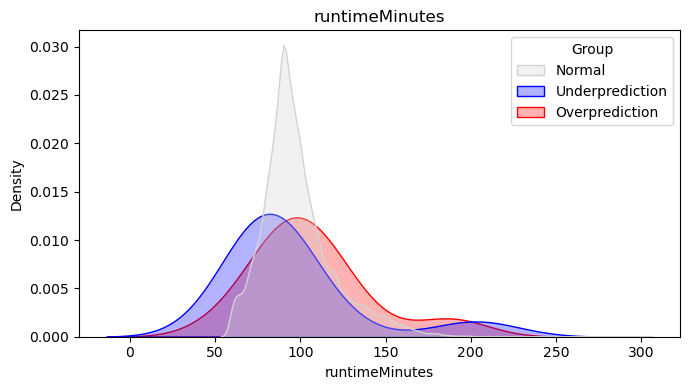

Group,Normal,Overprediction,Underprediction
ממוצע,98.535,106.3,95.1


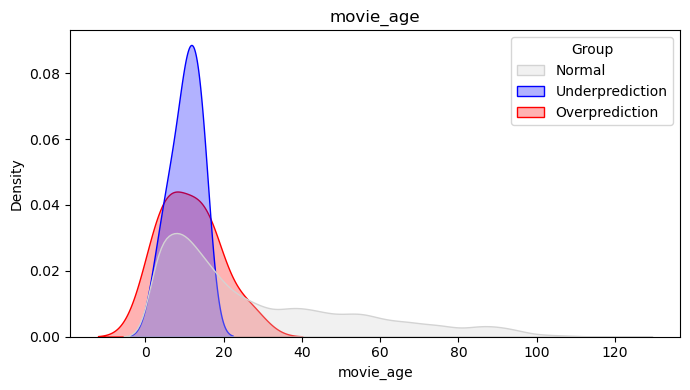

Group,Normal,Overprediction,Underprediction
ממוצע,28.582,11.3,10.2


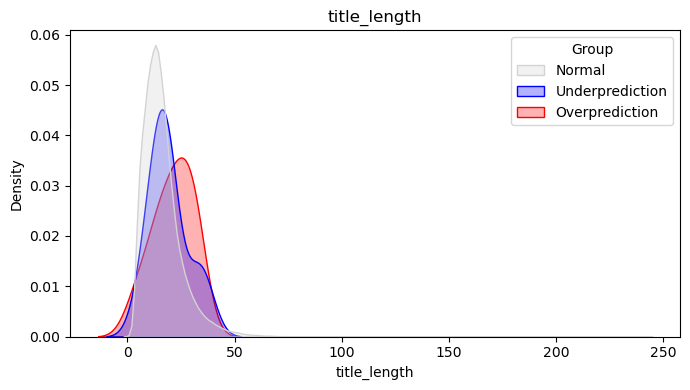

Group,Normal,Overprediction,Underprediction
ממוצע,16.111,21.2,19.1


In [15]:
plot_all_features(continuous_features, is_continuous=True)

Checking the runtimeMinutes variable showed a mild bias in the model's predictions. We found that the model consistently misses by a few minutes between the different error groups. Although this effect is not dramatic in terms of movie length (a difference of about 3 to 8 minutes on average), this trend shows that the model is overly sensitive to movie length and uses it as a sign of quality in a way that does not always match the audience's real rating.

Analyzing the title_length variable shows that the model consistently makes errors as the title gets longer. While normal predictions have an average title length of 16.1 characters, the error groups have longer titles (19.1 and 21.2 characters). This finding suggests that the model sees long titles as complex or unusual, which leads to a wrong prediction. The fact that the overprediction group has the longest titles (21.2) might show that the model connects long, descriptive titles with prestige or high quality, and therefore gives these movies higher scores even when their real rating is lower.

Binary variables:

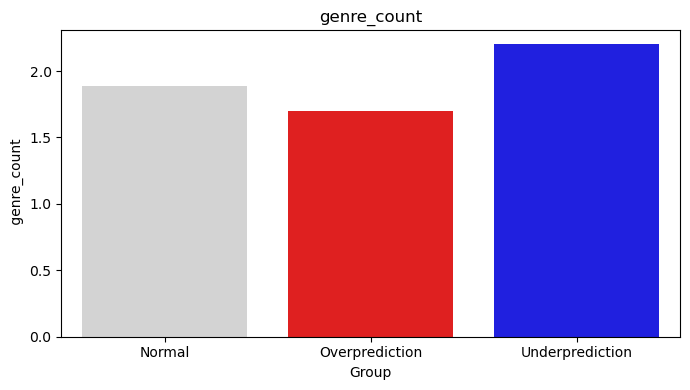

Group,Normal,Overprediction,Underprediction
ממוצע,1.89,1.7,2.2


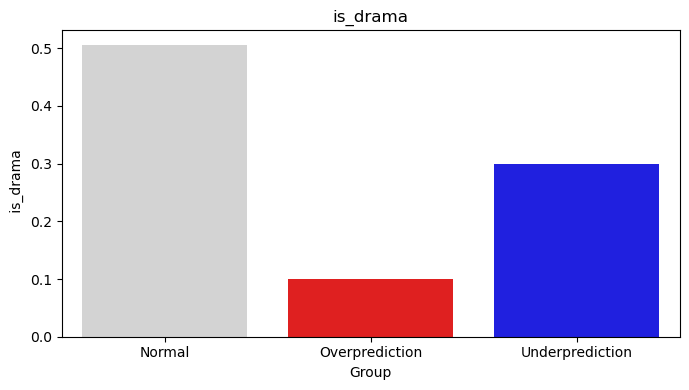

Group,Normal,Overprediction,Underprediction
ממוצע,0.506,0.1,0.3


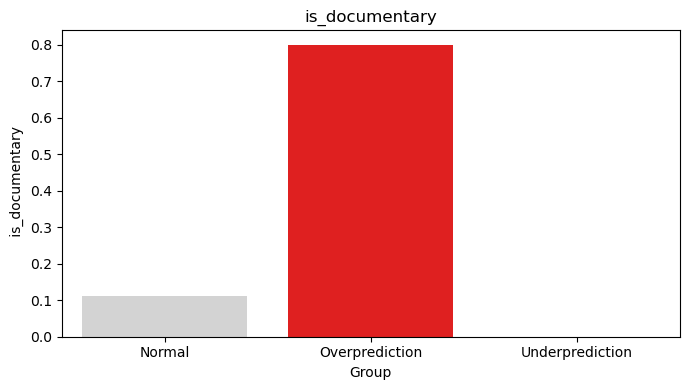

Group,Normal,Overprediction,Underprediction
ממוצע,0.112,0.8,0.0


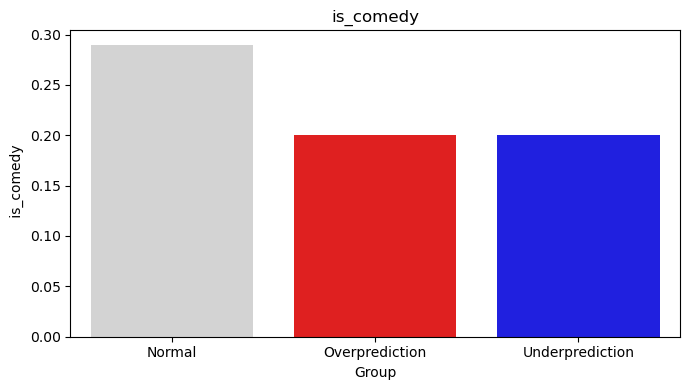

Group,Normal,Overprediction,Underprediction
ממוצע,0.29,0.2,0.2


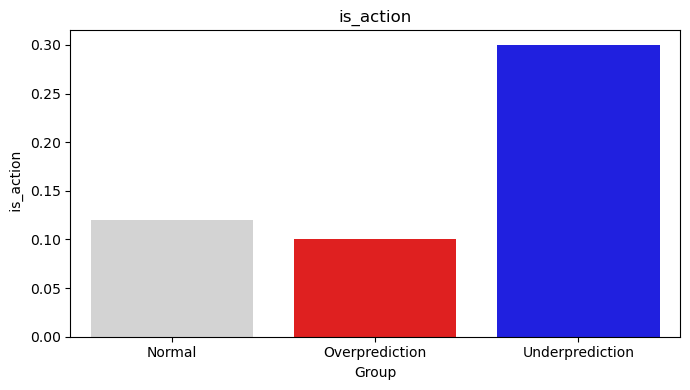

Group,Normal,Overprediction,Underprediction
ממוצע,0.12,0.1,0.3


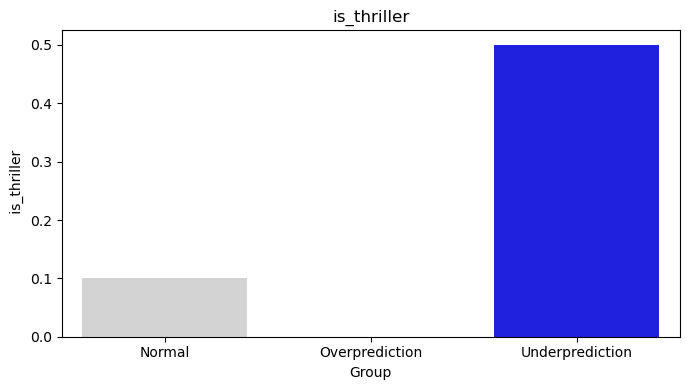

Group,Normal,Overprediction,Underprediction
ממוצע,0.101,0.0,0.5


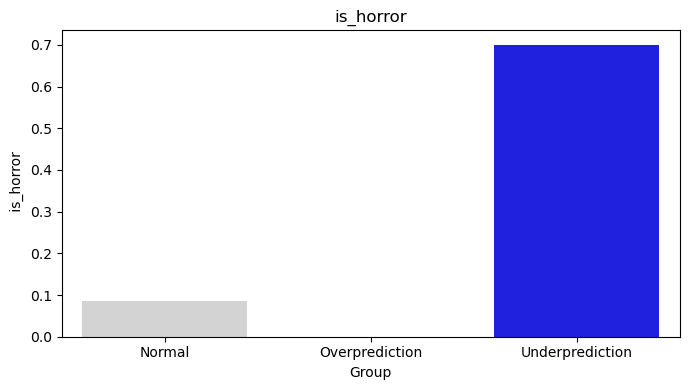

Group,Normal,Overprediction,Underprediction
ממוצע,0.086,0.0,0.7


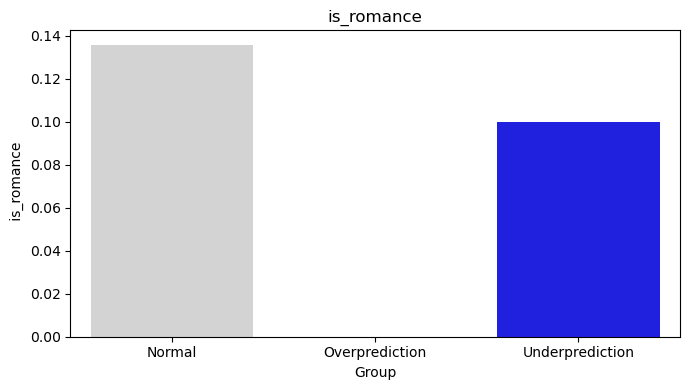

Group,Normal,Overprediction,Underprediction
ממוצע,0.136,0.0,0.1


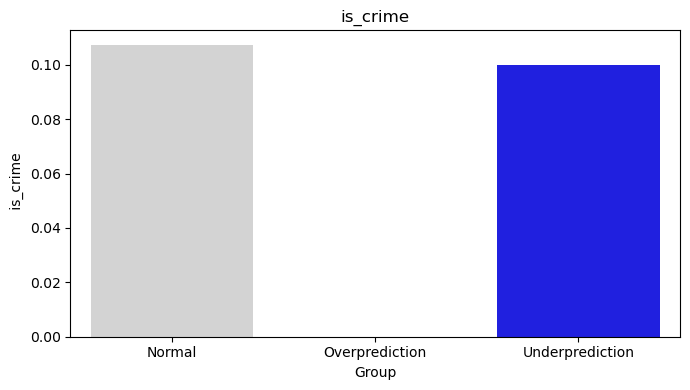

Group,Normal,Overprediction,Underprediction
ממוצע,0.107,0.0,0.1


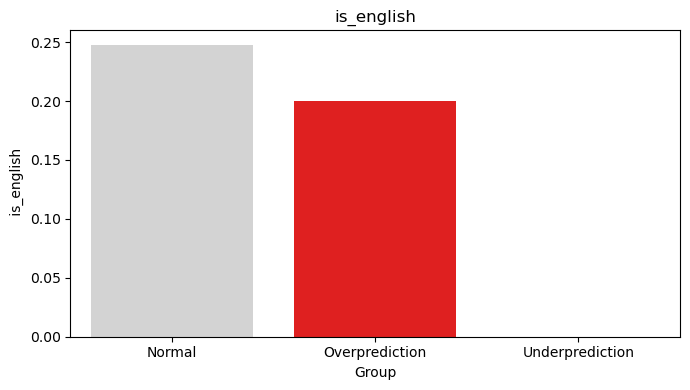

Group,Normal,Overprediction,Underprediction
ממוצע,0.248,0.2,0.0


In [16]:
plot_all_features(binary_and_discrete_features, is_continuous=False)

Analyzing the outliers showed a clear bias toward the documentary variable. While it appears moderately in normal predictions, it reaches 80% in the overprediction group. This shows that the model wrongly connects documentaries with high quality, giving them scores that are too high even when their real quality is lower.

Analyzing the drama genre shows that the model is quite accurate here. Only 10% of the overprediction group are drama movies, compared to 50% in the normal group. This suggests the model does not have a bias that overrates dramas. However, since dramas make up 30% of the underprediction group, it shows that when the model fails, it tends to 'punish' dramas and underrate them. This might happen because many drama movies rely on emotional nuances that the model struggles to measure using only technical features.

The error analysis for the action genre shows that the model struggles to overpredict these movies, as they make up a tiny 0.1% of this group. There is also a low representation of action movies in the underprediction group, but it is still three times higher than in the overprediction group. This indicates that the model is conservative or 'pessimistic' about action movies; it does not overrate them, and when it makes a mistake, it is more likely to give them a lower score than a higher one. The model might fail to recognize quality elements in action movies that audiences love, keeping a bias that lowers their value.

The error analysis for the action genre reveals a built-in bias toward underprediction. While action movies make up about 12% of normal predictions, they account for 30% of the cases where the model gave a score lower than the real one. This shows a 'conservative' approach to this genre; the model does not overrate action movies, but it tends to be harsh and give them scores below the real audience ratings. The model probably misses artistic or plot elements that make good action movies stand out, systematically lowering their value.

The error analysis for the thriller genre reveals a significant underprediction bias. While thriller movies make up only 10% of normal predictions, they represent 50% of the cases where the model failed and gave a lower score than the real one. This shows a clear difficulty in predicting ratings for thrillers; the model systematically underrates them compared to the audience's real scores. A model based on technical features likely fails to capture the 'suspense' or plot value of good thrillers, missing their high potential.

Analyzing the language distribution shows a major difference in underpredictions. While English movies make up about 24.8% of normal predictions, they are not present at all (0%) in the underprediction group. This shows a systematic bias in favor of English movies; the model avoids giving them scores that are too low and is less likely to 'punish' them compared to foreign-language movies. The model might have learned that English movies usually have higher production standards or wider appeal, making it more conservative and preventing extreme underpredictions for them.

The outlier analysis proves that the model does not make random mistakes; instead, it suffers from systematic biases. The overprediction group shows that the model tends to assign 'quality' to external technical features (like movie runtime and title length). On the other hand, the underprediction group reflects the model's difficulty in understanding the value of specific genres (like thrillers and action movies). This distinction highlights that the model has learned incorrect 'rules' about what makes a movie good, causing it to perform consistently but unevenly across different cases.

# 5.3 Model Comparison 

We will present the 20 largest errors for each model

In [17]:
y_pred_cv_en = cross_val_predict(grid_search.best_estimator_, X_train, y_train, cv=10)

comparison_df = pd.DataFrame({
    'Actual_Rating': y_train,
    'RF_Prediction': y_pred_cv, 
    'EN_Prediction': y_pred_cv_en
})

comparison_df['RF_Error'] = comparison_df['RF_Prediction'] - comparison_df['Actual_Rating']
comparison_df['EN_Error'] = comparison_df['EN_Prediction'] - comparison_df['Actual_Rating']

comparison_df['RF_Abs_Error'] = comparison_df['RF_Error'].abs()
comparison_df['EN_Abs_Error'] = comparison_df['EN_Error'].abs()

rf_top_20 = comparison_df.nlargest(20, 'RF_Abs_Error')
print("\n=== 20 השגיאות הגדולות ביותר של Random Forest ===")
display(rf_top_20.drop(columns=['EN_Prediction', 'EN_Error', 'EN_Abs_Error', 'RF_Abs_Error'], errors='ignore'))

en_top_20 = comparison_df.nlargest(20, 'EN_Abs_Error')
print("\n=== 20 השגיאות הגדולות ביותר של Elastic Net ===")
display(en_top_20.drop(columns=['RF_Prediction', 'RF_Error', 'RF_Abs_Error', 'EN_Abs_Error'], errors='ignore'))


=== 20 השגיאות הגדולות ביותר של Random Forest ===


,Actual_Rating,RF_Prediction,RF_Error
96377,1.5,7.616509,6.116509
16815,1.2,7.042493,5.842493
72010,1.3,7.124952,5.824952
12021,1.6,7.305162,5.705162
121915,1.6,7.271765,5.671765
45946,1.3,6.957872,5.657872
37806,1.5,7.090372,5.590372
81307,1.2,6.728036,5.528036
5086,1.7,7.221564,5.521564
72892,1.2,6.674362,5.474362



=== 20 השגיאות הגדולות ביותר של Elastic Net ===


,Actual_Rating,EN_Prediction,EN_Error
96377,1.5,8.454826,6.954826
72010,1.3,7.305414,6.005414
37806,1.5,7.438168,5.938168
16815,1.2,6.995632,5.795632
45946,1.3,7.012274,5.712274
5086,1.7,7.373203,5.673203
104680,1.5,7.162315,5.662315
12021,1.6,7.199985,5.599985
121915,1.6,7.138445,5.538445
83052,2.0,7.372772,5.372772


We will check how many of them overlap:

In [18]:
common_outliers_index = rf_top_20.index.intersection(en_top_20.index)
common_outliers = comparison_df.loc[common_outliers_index]

print(f"\n=== Found {len(common_outliers)} overlapping errors (shared outliers) in both models ===")
columns_to_show = ['Actual_Rating', 'RF_Prediction', 'EN_Prediction', 'RF_Error', 'EN_Error']
display(common_outliers[columns_to_show])


=== Found 14 overlapping errors (shared outliers) in both models ===


,Actual_Rating,RF_Prediction,EN_Prediction,RF_Error,EN_Error
96377,1.5,7.616509,8.454826,6.116509,6.954826
16815,1.2,7.042493,6.995632,5.842493,5.795632
72010,1.3,7.124952,7.305414,5.824952,6.005414
12021,1.6,7.305162,7.199985,5.705162,5.599985
121915,1.6,7.271765,7.138445,5.671765,5.538445
45946,1.3,6.957872,7.012274,5.657872,5.712274
37806,1.5,7.090372,7.438168,5.590372,5.938168
5086,1.7,7.221564,7.373203,5.521564,5.673203
90191,1.8,7.192622,7.056670,5.392622,5.256670
83052,2.0,7.390823,7.372772,5.390823,5.372772


Out of 40 errors, there are 14 errors shared by both models.
It can be seen that there is always one model that makes smaller errors, but the differences are not very large.

Let's look at movies where one model was right and the other failed:

In [19]:
comparison_df['RF_Error'] = comparison_df['RF_Prediction'] - comparison_df['Actual_Rating']
comparison_df['EN_Error'] = comparison_df['EN_Prediction'] - comparison_df['Actual_Rating']

comparison_df['RF_Abs_Error'] = comparison_df['RF_Error'].abs()
comparison_df['EN_Abs_Error'] = comparison_df['EN_Error'].abs()

comparison_df['EN_vs_RF_Diff'] = comparison_df['EN_Abs_Error'] - comparison_df['RF_Abs_Error']
comparison_df['RF_vs_EN_Diff'] = comparison_df['RF_Abs_Error'] - comparison_df['EN_Abs_Error']

en_unique_fails = comparison_df.nlargest(10, 'EN_vs_RF_Diff')
rf_unique_fails = comparison_df.nlargest(10, 'RF_vs_EN_Diff')

print("=== Unique Errors for ElasticNet ===")
display(en_unique_fails[['Actual_Rating', 'EN_Prediction', 'RF_Prediction', 'EN_Abs_Error', 'RF_Abs_Error']])

print("\n=== Unique Errors for Random Forest ===")
display(rf_unique_fails[['Actual_Rating', 'EN_Prediction', 'RF_Prediction', 'EN_Abs_Error', 'RF_Abs_Error']])

=== Unique Errors for ElasticNet ===


,Actual_Rating,EN_Prediction,RF_Prediction,EN_Abs_Error,RF_Abs_Error
6224,8.8,5.469378,7.523784,3.330622,1.276216
97283,8.3,5.377212,7.311101,2.922788,0.988899
76599,4.9,6.868297,4.938869,1.968297,0.038869
71289,5.4,8.525750,6.623037,3.125750,1.223037
19556,5.5,7.623982,5.737494,2.123982,0.237494
105629,5.5,9.094398,7.213167,3.594398,1.713167
14548,7.2,5.248235,7.060764,1.951765,0.139236
126927,8.7,6.350180,8.125931,2.349820,0.574069
47779,8.4,5.448394,7.216288,2.951606,1.183712
4101,7.2,5.448155,7.192748,1.751845,0.007252



=== Unique Errors for Random Forest ===


,Actual_Rating,EN_Prediction,RF_Prediction,EN_Abs_Error,RF_Abs_Error
101778,8.4,8.343989,6.193305,0.056011,2.206695
82035,7.4,7.348688,5.466764,0.051312,1.933236
90302,7.5,7.310905,5.447112,0.189095,2.052888
106525,9.5,9.149069,7.347098,0.350931,2.152902
42294,8.5,8.458222,6.722694,0.041778,1.777306
49080,5.9,5.469057,3.738317,0.430943,2.161683
109058,5.0,5.689286,7.401562,0.689286,2.401562
73360,5.0,5.603640,7.301895,0.603640,2.301895
47176,4.3,5.389081,7.039830,1.089081,2.739830
99,8.5,7.070814,5.438283,1.429186,3.061717


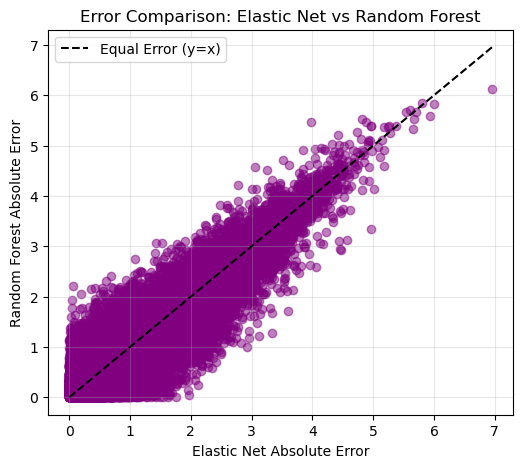

In [20]:
plt.figure(figsize=(6, 5))
plt.scatter(comparison_df['EN_Abs_Error'], comparison_df['RF_Abs_Error'], alpha=0.5, color='purple')

max_error = max(comparison_df['EN_Abs_Error'].max(), comparison_df['RF_Abs_Error'].max())
plt.plot([0, max_error], [0, max_error], 'k--', label='Equal Error (y=x)')

plt.title("Error Comparison: Elastic Net vs Random Forest")
plt.xlabel("Elastic Net Absolute Error")
plt.ylabel("Random Forest Absolute Error")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

An examination of the absolute error distribution between the two models (see graph) reveals several insights. First, there is a high density around the line of equality (y=x), indicating a strong correlation in model performance—observations that were challenging to predict for the linear model were typically challenging for the tree-based model as well. However, the dispersion of points on both sides of the line illustrates the relative advantage of each model: observations below the line represent cases where the Random Forest successfully captured non-linear patterns that ElasticNet missed, while observations above the line indicate outliers where the linear model demonstrated greater stability.

# 5.4 Proposed Improvements

1. Feature: Genre "Depth" Metric

The Feature: A metric to measure the "depth" or scale of the genre. For example: the number of well-known (A-list) actors starring in the movie, or the production budget rating.

How it solves the issue: High-quality thriller and action movies are often those with high budgets and leading actors. This feature will allow the model to distinguish between a "low-budget thriller" (which might genuinely be subpar) and a "high-end Hollywood thriller" (which deserves a higher rating). This will help reduce the underprediction bias in these specific genres.

2. Feature: Runtime ,Genre Interaction Variable

The Feature: Creating a new interaction term: runtime * genre.

How it solves the issue: Instead of the model looking at runtimeMinutes on its own, it will evaluate a combined value. This will teach the model that a 90-minute action movie is perfectly fine (rather than a "short movie that should be penalized"), while a 90-minute drama is considered standard. This "normalizes" the model's expectations based on the specific type of movie.

# 6.1+6.2 Required Breakdowns and Visualizations

## Genre Breakdown:

=== Top 5 Most Common Genres ===


,RMSE,MAE,כמות סרטים
Drama,1.059,0.807,46734.0
Comedy,1.132,0.867,26777.0
['Drama'],1.102,0.846,6495.0
Documentary,1.000,0.736,10400.0
Romance,1.021,0.775,12540.0


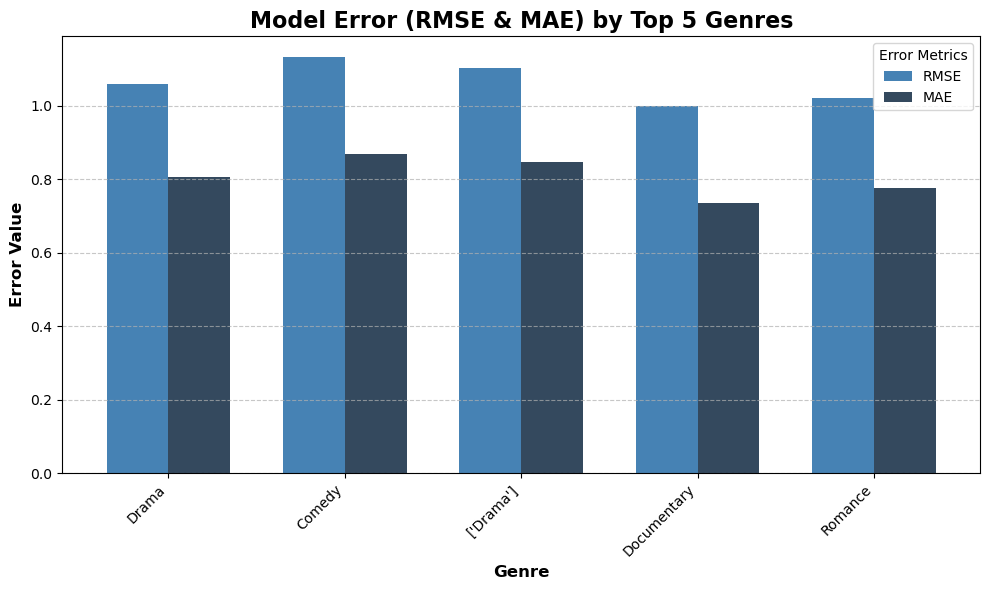

In [21]:
all_genres = df['genres'].dropna().astype(str).str.split(',').explode().str.strip()
all_genres = all_genres[~all_genres.isin(['\\N', 'nan', 'NaN', ''])]
top_5_genres = all_genres.value_counts().head(5).index.tolist()

analysis_df = comparison_df.copy()
analysis_df['raw_genres'] = df.loc[analysis_df.index, 'genres'].astype(str)

def calculate_fairness_metrics(group, error_col):
    rmse = np.sqrt((group[error_col] ** 2).mean())
    mae = group[error_col].abs().mean()
    count = len(group)
    return pd.Series({'RMSE': round(rmse, 3), 'MAE': round(mae, 3), 'כמות סרטים': count})

genre_results = []

for genre in top_5_genres:
    subset = analysis_df[analysis_df['raw_genres'].str.contains(genre, case=False, regex=False)]
    
    if len(subset) > 0:
        metrics = calculate_fairness_metrics(subset, 'RF_Error')
        metrics.name = genre
        genre_results.append(metrics)

print("=== Top 5 Most Common Genres ===")
genre_slice = pd.DataFrame(genre_results)
display(genre_slice)

ax = genre_slice[['RMSE', 'MAE']].plot(
    kind='bar', 
    figsize=(10, 6), 
    color=['#4682b4', '#34495e'], 
    width=0.7
)

plt.title('Model Error (RMSE & MAE) by Top 5 Genres', fontsize=16, fontweight='bold')
plt.xlabel('Genre', fontsize=12, fontweight='bold')
plt.ylabel('Error Value', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Error Metrics')
plt.tight_layout()
plt.show()

## חתך לפי עשור יציאה:

=== By Release Decade ===


,RMSE,MAE,כמות סרטים
Decade,,,
1980s,1.068,0.837,7698.0
1990s,1.074,0.835,8150.0
2000s,1.147,0.876,14058.0
2010s,1.180,0.895,26886.0
2020s,1.256,0.958,14722.0


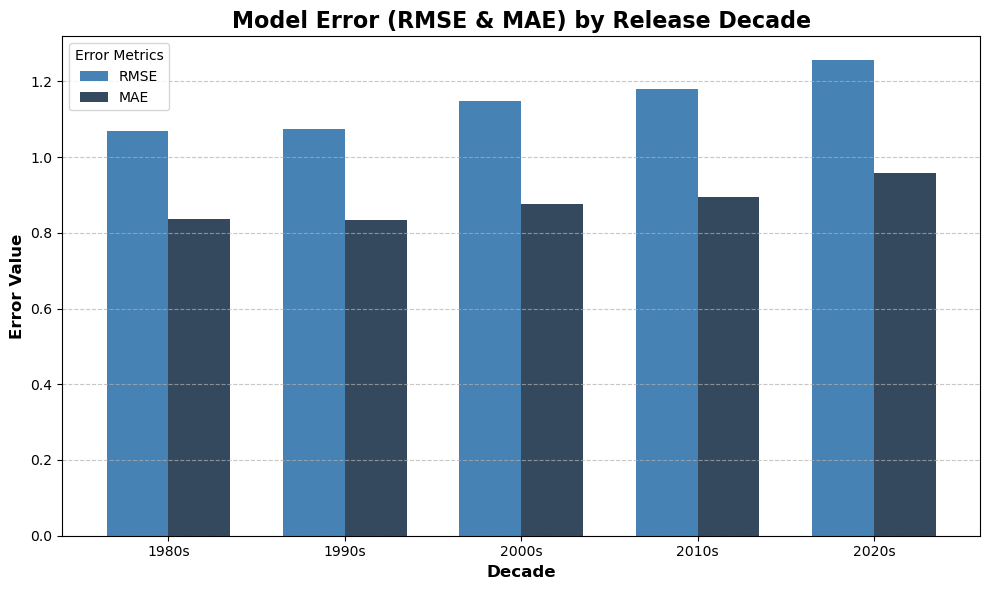

In [22]:
analysis_df_decade = comparison_df.copy()
analysis_df_decade['startYear'] = pd.to_numeric(df.loc[analysis_df_decade.index, 'startYear'], errors='coerce')
analysis_df_decade['Decade'] = (analysis_df_decade['startYear'] // 10) * 10
recent_decades = analysis_df_decade[analysis_df_decade['Decade'] >= 1980].copy()

decade_slice = recent_decades.groupby('Decade').apply(calculate_fairness_metrics, error_col='RF_Error')
decade_slice.index = decade_slice.index.astype(int).astype(str) + 's'

print("=== By Release Decade ===")
display(decade_slice)

ax = decade_slice[['RMSE', 'MAE']].plot(
    kind='bar', 
    figsize=(10, 6), 
    color=['#4682b4', '#34495e'], 
    width=0.7
)

plt.title('Model Error (RMSE & MAE) by Release Decade', fontsize=16, fontweight='bold')
plt.xlabel('Decade', fontsize=12, fontweight='bold')
plt.ylabel('Error Value', fontsize=12, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Error Metrics')
plt.tight_layout()
plt.show()

# 7. Feature Importance Analysis

We will identify the top 5 most important features for each model:

In [23]:
best_model_en = grid_search.best_estimator_.named_steps['model']
en_coefs = best_model_en.coef_

en_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': en_coefs,
    'Abs_Importance': np.abs(en_coefs)
})

en_importance_df['Feature'] = en_importance_df['Feature'].str.replace('bin_', '').str.replace('cont_', '').str.lstrip('_').str.strip()

en_top_5 = en_importance_df.sort_values(by='Abs_Importance', ascending=False).head(5).copy()
en_top_5['Direction'] = np.where(en_top_5['Coefficient'] > 0, 'חיובי (+)', 'שלילי (-)')

print("=== Top 5 Most Influential Features in ElasticNet ===")
display(en_top_5[['Feature', 'Coefficient', 'Direction']])

=== Top 5 Most Influential Features in ElasticNet ===


,Feature,Coefficient,Direction
5,is_documentary,0.421237,חיובי (+)
9,is_horror,-0.253462,שלילי (-)
0,runtimeMinutes,0.244333,חיובי (+)
4,is_drama,0.145688,חיובי (+)
7,is_action,-0.132573,שלילי (-)


In [24]:
feature_names = ['runtimeMinutes', 'title_length', 'genre_count', 'movie_age',
                 'is_english', 'is_drama', 'is_documentary', 'is_comedy', 
                 'is_action', 'is_thriller', 'is_horror', 'is_romance', 'is_crime']

rf_pipeline.fit(X_train, y_train)

perm_result = permutation_importance(
    rf_pipeline, 
    X_train, 
    y_train, 
    n_repeats=10, 
    random_state=42, 
    n_jobs=-1
)

rf_perm_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_result.importances_mean
})

rf_perm_df['Feature'] = rf_perm_df['Feature'].str.replace('bin_', '').str.replace('cont_', '').str.lstrip('_').str.strip()
rf_top_5 = rf_perm_df.sort_values(by='Importance', ascending=False).head(5).copy()

correlations = X_train.corrwith(y_train)
corr_dict = {
    col.replace('bin_', '').replace('cont_', '').lstrip('_'): 'חיובי (+)' if val > 0 else 'שלילי (-)'
    for col, val in correlations.items()
}
rf_top_5['Direction'] = rf_top_5['Feature'].map(corr_dict)
print("\n=== Top 5 Features: Random Forest ===")
display(rf_top_5[['Feature', 'Importance', 'Direction']])


=== Top 5 Features: Random Forest ===


,Feature,Importance,Direction
0,runtimeMinutes,0.274409,חיובי (+)
1,title_length,0.213264,חיובי (+)
5,is_drama,0.204123,חיובי (+)
9,is_thriller,0.118412,שלילי (-)
4,is_english,0.108112,שלילי (-)


In [25]:
print("Elastic Net Features:", en_top_5["Feature"].tolist())
print("Random Forest Features:",rf_top_5["Feature"].tolist())

Elastic Net Features: ['is_documentary', 'is_horror', 'runtimeMinutes', 'is_drama', 'is_action']
Random Forest Features: ['runtimeMinutes', 'title_length', 'is_drama', 'is_thriller', 'is_english']


We will visualize the data to see which features are shared by both models and which are unique

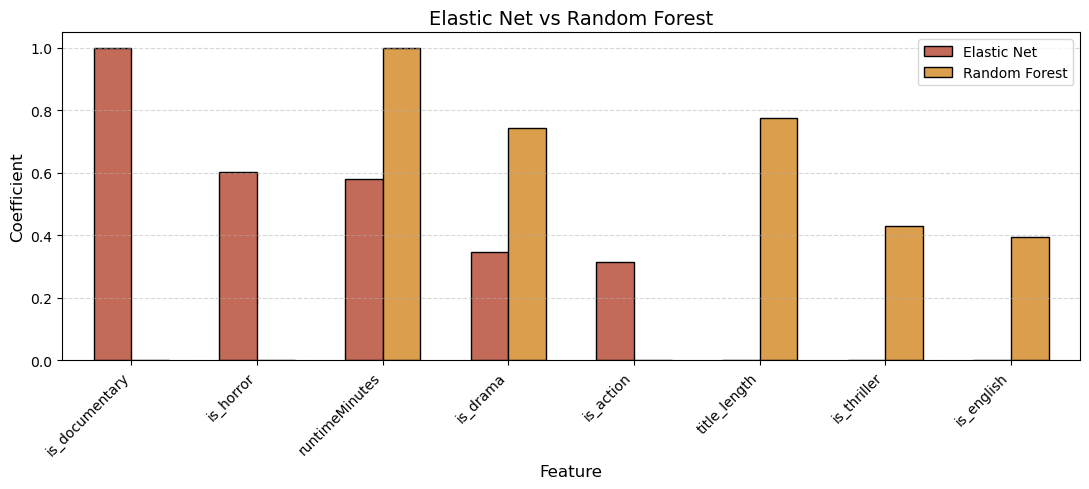

In [26]:
en_top_5 = en_top_5.copy()
rf_top_5 = rf_top_5.copy()

en_top_5['Norm_Importance'] = en_top_5['Abs_Importance'] / en_top_5['Abs_Importance'].max()
rf_top_5['Norm_Importance'] = rf_top_5['Importance'] / rf_top_5['Importance'].max()

comparison = pd.merge(
    en_top_5[['Feature', 'Norm_Importance']], 
    rf_top_5[['Feature', 'Norm_Importance']], 
    on='Feature', 
    how='outer', 
    suffixes=('_EN', '_RF')
).set_index('Feature').fillna(0)

comparison.columns = ['Elastic Net', 'Random Forest']

fig, ax = plt.subplots(figsize=(11, 5))

comparison.plot(kind='bar', ax=ax, color=['#c36a59', '#db9e4c'], edgecolor='black', width=0.6)

plt.title("Elastic Net vs Random Forest", fontsize=14)
plt.xlabel("Feature", fontsize=12)
plt.ylabel("Coefficient", fontsize=12)
plt.xticks(rotation=45, ha='right') 
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()

The analysis of our graph shows that both models agree on runtimeMinutes and is_drama as important features. This confirms that these two variables have a genuine impact on a movie's rating, regardless of the algorithm used.
However, the two models differ on the remaining features due to their distinct underlying mechanics. On one hand, Elastic Net highlights is_documentary and is_horror because it captures direct and proportional linear effects. On the other hand, Random Forest prefers a variable like title_length because it operates through non-linear decision splits and thresholds. 

We will compare the features shared by both models and analyze their directions of influence:

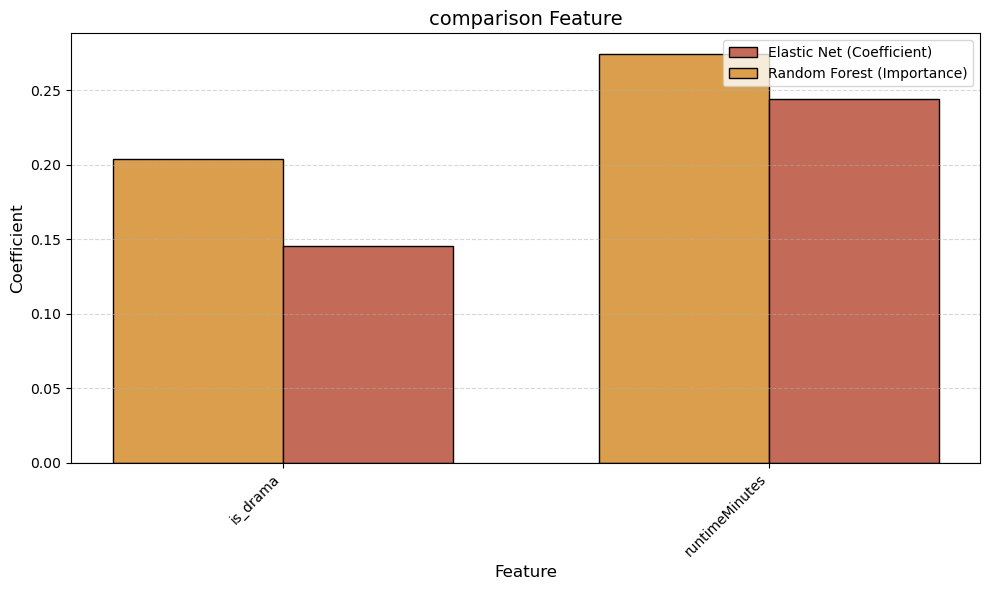

In [27]:
import matplotlib.patches as mpatches
comparison_raw = pd.DataFrame({
    'Elastic Net': en_top_5.set_index('Feature')['Coefficient'],
    'Random Forest': rf_top_5.set_index('Feature')['Importance']
}).fillna(0)

comparison_filtered = comparison_raw[
    (comparison_raw['Elastic Net'] != 0) & (comparison_raw['Random Forest'] > 0)
].copy()

features = comparison_filtered.index.tolist()
en_values = comparison_filtered['Elastic Net'].tolist()
rf_values = comparison_filtered['Random Forest'].tolist()

en_colors = ['#c36a59' if x >= 0 else '#d62728' for x in en_values]
rf_color = '#db9e4c'

x = np.arange(len(features))  
width = 0.35                  

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, rf_values, width, color=rf_color, edgecolor='black')
rects2 = ax.bar(x + width/2, en_values, width, color=en_colors, edgecolor='black')

ax.set_title("comparison Feature", fontsize=14)
ax.set_xlabel("Feature", fontsize=12)
ax.set_ylabel("Coefficient", fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(features, rotation=45, ha='right')
ax.axhline(0, color='black', linewidth=0.8)
ax.grid(axis='y', linestyle='--', alpha=0.5)

patch_rf = mpatches.Patch(facecolor='#db9e4c', edgecolor='black', label='Random Forest (Importance)')
patch_en = mpatches.Patch(facecolor='#c36a59', edgecolor='black', label='Elastic Net (Coefficient)')

ax.legend(handles=[patch_en, patch_rf], loc='upper right')

plt.tight_layout()
plt.show()

We can see that both models identify the same core variables: the movie's duration (runtimeMinutes) and whether it belongs to the drama genre (is_drama). This suggests that these two features play a major role in predicting movie ratings.
However, the Random Forest model gives a higher importance to the movie's duration than the Elastic Net model. This indicates that Random Forest is capable of capturing more complex and non-linear relationships between a movie's length and its rating, while Elastic Net only models a fixed average effect.

Overall, this comparison shows that both models agree on the main explanatory factors. However, Random Forest takes better advantage of the complex interactions and structures in the data, which explains its better overall performance during evaluation.

In [28]:
X_final = df_final.drop(columns=['averageRating'])
y_final = df_final['averageRating']

best_rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, max_depth=16, min_samples_leaf=4, random_state=42, n_jobs=-1))
])

print("Training the final Random Forest model...")
best_rf_pipeline.fit(X_final, y_final)

output_filename = 'model.pkl'
joblib.dump(best_rf_pipeline, output_filename, compress=3)
print(f"Success! The compressed serialized pipeline has been saved as '{output_filename}'")

Training the final Random Forest model...
Success! The compressed serialized pipeline has been saved as 'model.pkl'
